# <center> Практические задания по цифровой обработке сигналов </center>
# <center> Вторая лабораторная работа </center>
# <center> Анализ сигналов </center>

In [389]:
import librosa
import numpy as np
import scipy 
import scipy.fft
import IPython.display as ipd
import matplotlib.pyplot as plt
import librosa.display
import librosa.filters
import hashlib

# Запретим numpy выполнять деление на 0
np.seterr(divide='raise', invalid='raise') 
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [139]:
# Определим две функции для отрисовки сигнала. 
def draw_waveform(wav, sr, figsize=(14, 5)):
    # Отрисовка звукового сигнала во временной области
    plt.figure(figsize=figsize)
    librosa.display.waveshow(wav, sr=sr)

def draw_sig(frames, name=None, figsize=(14, 3)):
    # Отрисовка сигнала в виде "леденцов на палочке"
    plt.figure(figsize=figsize)
    plt.stem(frames)
    if name is not None:
        plt.legend([name])
    plt.xlabel("n")
    plt.ylabel("Energy")
    plt.show()
    

Создадим несколько простых сигналов. Они нам понадобятся для дальшейшего тестирования

signals = {}

### Единичный импульс

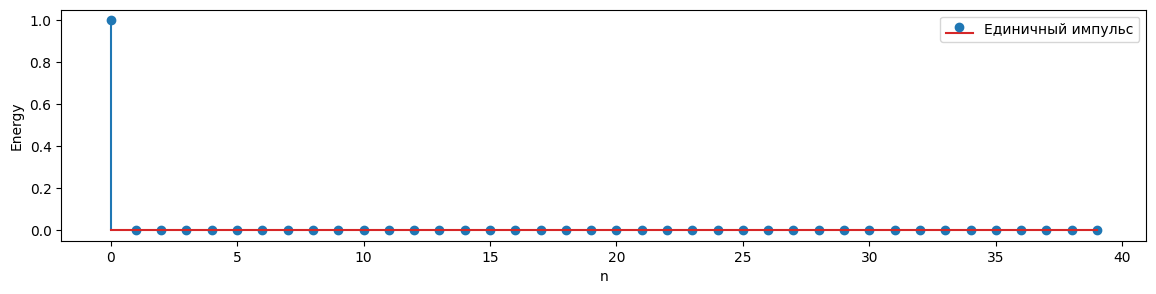

In [18]:
signals = {}
name = "Единичный импульс"
signals[name] = np.array([1] + [0]*39, dtype=float)
draw_sig(signals[name], name)

### Единичный скачок

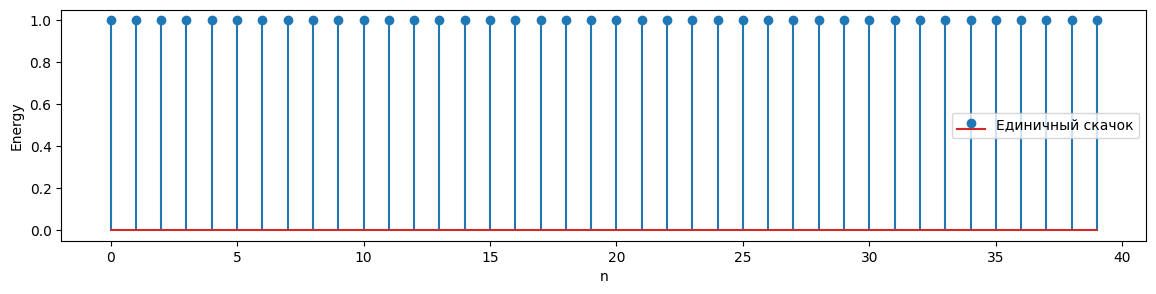

In [20]:
name = "Единичный скачок"
signals[name] = np.array([1]*40 ,dtype=float) 
draw_sig(signals[name], name)

### Синус

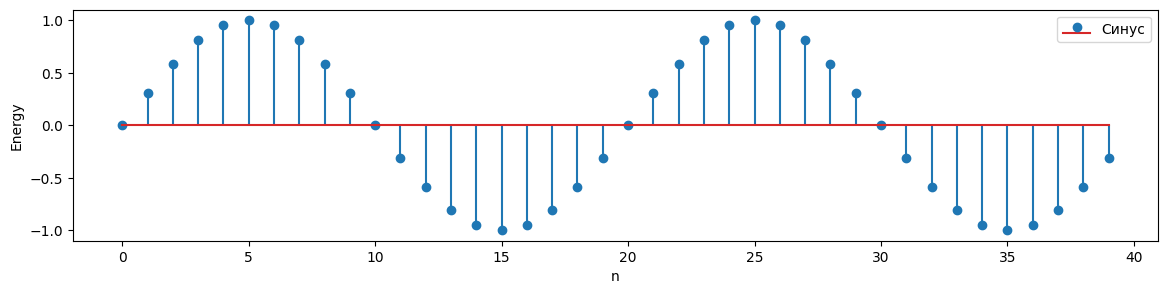

In [22]:
name = "Синус"
signals[name] = np.sin(np.pi * np.arange(40)/10)
draw_sig(signals[name], name)

### Шум

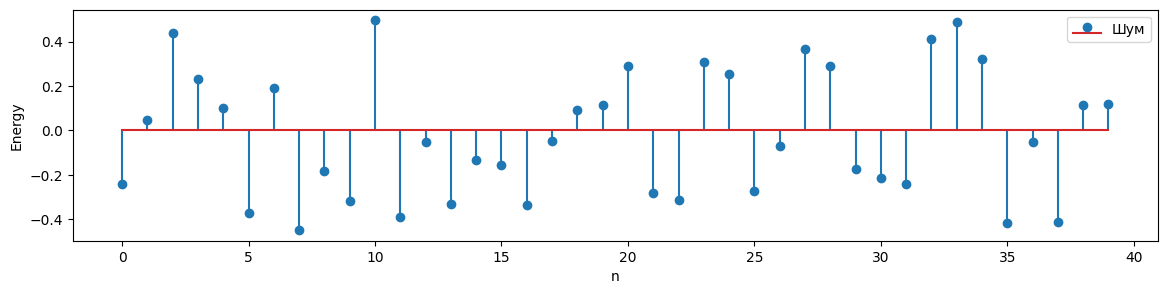

In [24]:
name = "Шум"
signals[name] = np.random.random(40)-0.5
draw_sig(signals[name], name)

-------------------------------
# Преобразование Фурье
Прежде, чем перейти к анализу сигналов, надо разобраться, что такое преобразование Фурье. 
> Преобразование Фурье (символ ℱ) — операция, сопоставляющая одной функции вещественной переменной другую функцию вещественной переменной. Эта новая функция описывает коэффициенты («амплитуды») при разложении исходной функции на элементарные составляющие — гармонические колебания с разными частотами (подобно тому, как музыкальный аккорд может быть выражен в виде суммы музыкальных звуков, которые его составляют). [Wiki](https://ru.wikipedia.org/wiki/%D0%9F%D1%80%D0%B5%D0%BE%D0%B1%D1%80%D0%B0%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D0%A4%D1%83%D1%80%D1%8C%D0%B5)



Формула прямого дискретного преобразования Фурье (ДПФ, Discrete Fourier Transform, DFT):
$$ X_k = \sum_{n=0}^{N-1} x_{n} \cdot e^{-i \frac{2\pi}{N} k n} $$


# Задание 1 (2 балла)
Реализовать дискретное преобразование Фурье. Сравнить с реализацией *scipy.fft.fft*

In [30]:
def DFT(x):
    N = len(x)
    n = np.arange(N)
    k = n.reshape((N, 1))
    e = np.exp(-2j*np.pi*k*n/N)
    x = np.dot(x, e)

    return x

Сравнение с библиотекой scipy

In [32]:
def test_DTF(x, transform=DFT):
    scipy_result = scipy.fft.fft(x)
    curr_result = transform(x)
    if scipy_result.shape != curr_result.shape:
        print("TEST_FAILED")
        print(f"Your spectrogram shape is {curr_result.shape}. "
              f"Scipy spectrogram shape is {scipy_result.shape}")
        return -1
    if not np.allclose(curr_result, scipy_result):
        print("TEST FAILED")
        print(f"scipy spectrogram: {scipy_result}")
        print(f"Your DTF spectrogram: {curr_result}")
        print(f"Average diff is {np.mean(np.abs(scipy_result - curr_result))}")
        return -2
    print("TEST PASSED")
    return 0

for name, sig in signals.items():
    print(f"Checking '{name}'")
    assert test_DTF(sig) == 0, "Check you implementation"
print("All ok!")

Checking 'Единичный импульс'
TEST PASSED
Checking 'Единичный скачок'
TEST PASSED
Checking 'Синус'
TEST PASSED
Checking 'Шум'
TEST PASSED
All ok!


Класическое ДПФ имеет существенный недостаток - сложность алгоритма $O(N^2)$. На данный момент существуют чуть более сложные реализации преобразования Фурье, которые избавляются от квадратичной сложности. Например, алгоритм быстрого преобразования Фурье (Fast Fourier Transform, FFT) имеет сложность $O(N log(N))$, что делает его значительно более быстрым на длинных последовательностях. 

# Задание 1.1* (1 балл)
Реализовать быстрое преобразование Фурье. Сравнить с scipy.fft.fft

**Подсказка:** учтите, что для БПФ нам нужно, чтобы количество отсчетов сигнала было степенью двойки

In [279]:
def _DFT_simple(x):
    L = len(x)
    n = np.arange(L)
    result = np.empty(L, dtype=complex)
    for freq_bin in range(L):
        exponent = -2j * np.pi * freq_bin * n / L
        result[freq_bin] = np.sum(x * np.exp(exponent))
    return result

def FFT(signal):
    signal_length = len(signal)
    if signal_length == 0:
        return np.array([], dtype=np.complex128)

    if (signal_length & (signal_length - 1)) != 0:
        return _DFT_simple(signal)

    # Bit reversal permutation
    log2_N = int(np.log2(signal_length))
    reversed_indices = np.empty(signal_length, dtype=int)
    for original_index in range(signal_length):
        reversed_index = 0
        temp = original_index
        for _ in range(log2_N):
            reversed_index = (reversed_index << 1) | (temp & 1)
            temp >>= 1
        reversed_indices[original_index] = reversed_index

    reordered_signal = signal[reversed_indices].copy()
    current_size = 2
    while current_size <= signal_length:
        half_size = current_size // 2
        rotation_factor = np.exp(-2j * np.pi / current_size)
        
        for block_start in range(0, signal_length, current_size):
            current_factor = 1.0 + 0j
            for position in range(half_size):
                even_part = reordered_signal[block_start + position]
                odd_part = current_factor * reordered_signal[block_start + position + half_size]
                
                reordered_signal[block_start + position] = even_part + odd_part
                reordered_signal[block_start + position + half_size] = even_part - odd_part
                current_factor *= rotation_factor
                
        current_size *= 2

    return reordered_signal

In [281]:
for name, sig in signals.items():
    print(f"Checking '{name}'")
    assert test_DTF(sig, transform=FFT) == 0, "Check you implementation"
print("All ok!")

Checking 'Единичный импульс'
TEST PASSED
Checking 'Единичный скачок'
TEST PASSED
Checking 'Синус'
TEST PASSED
Checking 'Шум'
TEST PASSED
All ok!


Если вы изменяли длительность исходных сигналов, не забудьте вернуть их изначальную длительность

In [ ]:
# YOUR CODE HERE

# Амплитудный и фазовый спектры
Поскольку преобразование Фурье определено в комплекстной области, анализировать результат напрямую проблематично. Для анализа сигналов принято разбивать результат преобразования Фурье на два спектра: амплитудный и фазовый. Амплитудный показывает, как меняется модуль сигнала, а фазовый - как меняется угол, образуемый на комплексной плоскости. 
# Задание 2 (1 балл)

Реализовать функции построения амплитудного и фазового спектра

In [73]:
#функция построения амплитудного спектра
def get_amplitude_from_spec(spec):
    amplitude = np.abs(spec)
    return amplitude

#функция построения фазового спектра
def get_phi_from_spec(spec):
    phase_spec = np.angle(spec)
    return(phase_spec)

In [75]:
def check_mean_var(sig, mean=None, var=None):
    if mean is not None and np.mean(sig) != mean:
        print(f"Bad mean. Expected {mean}, got {np.mean(sig)}")
        return False
    if var is not None and np.var(sig) != var:
        print(f"Bad var. Expected {var}, got {np.var(sig)}")
        return False
    return True

_spec = scipy.fft.fft(np.array([1]+[0]*10))
assert check_mean_var(get_amplitude_from_spec(_spec), 1.0, 0.0), \
    "Wrong Amplitude"
assert check_mean_var(get_phi_from_spec(_spec), 0.0, 0.0), \
    "Wrong Phase"

    
_spec = scipy.fft.fft(np.array([1]*10))
assert check_mean_var(get_amplitude_from_spec(_spec), 1.0, 9.0), \
    "Wrong  Amplitude"
assert get_amplitude_from_spec(_spec)[0] == 10, \
    "Wrong Amplitude"
assert get_phi_from_spec(_spec)[0] == 0, \
    "Wrong phase"

_spec = scipy.fft.fft(scipy.fft.ifft(np.array([0] + [10+5j]+[0]*6 + [10-5j])))
assert get_amplitude_from_spec(_spec).round(1)[1] == 11.2 , \
    "Wrong Amplitude. Make sure it is a complex number module."
assert get_phi_from_spec(_spec).round(1)[1] == 0.5 , \
    "Wrong Amplitude. Make sure it is an angle."

   
print("All OK!")

All OK!


Определим еще одну функцию для отрисовки. Теперь будем рисовать сигнал в частотной области

In [77]:
def draw_spec(spec, name=None, draw_A=True, draw_p=True, figsize=(14, 3)):
    if len(spec)<100:
        # Рисуем точки как "леденцы на палочках"
        draw_func = plt.stem
    else:
        # При большом N "леденцы" выглядят плохо, 
        # Поэтому будем рисовать огибающую функцию
        draw_func = plt.plot
    
    if draw_A:
        plt.figure(figsize=figsize)
        plt.title("Amplitude spectrum")
        spec_A = get_amplitude_from_spec(spec)
        draw_func(spec_A)
        plt.ylabel("Magnitude")
        plt.xlabel("n")
        if name is not None:
            plt.legend([name])
        plt.show()
        
    if draw_p:
        plt.figure(figsize=figsize)
        plt.title("Phase spectrum")
        phi = get_phi_from_spec(spec)
        draw_func(phi)
        plt.ylabel("Radian")
        plt.xlabel("n")
        if name is not None:
            plt.legend([name])
        plt.show()
    return 

# Задание 2.1 (0.5 балла)
Постройте спектры для всех сигналов из коллекции signals и ответьте на вопросы:
<!-- 1. Почему амплитуда всех гармоник единичного импульса равна единице? 
1. Какие выводы можно сделать смотря на амплитудный спектр? А на фазовый? 
1. Как перевести номер отсчета в частоту?  
1. Что в фазовом спектре является полезной информацией, а что - шумом? Почему? -->

### Визуализация:

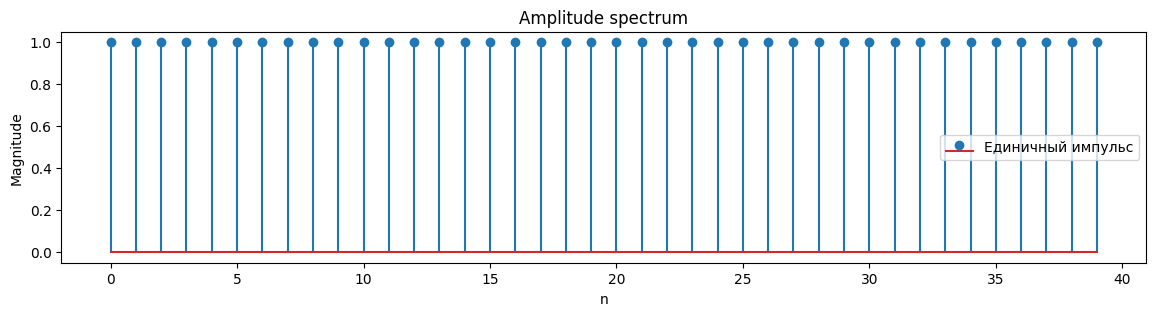

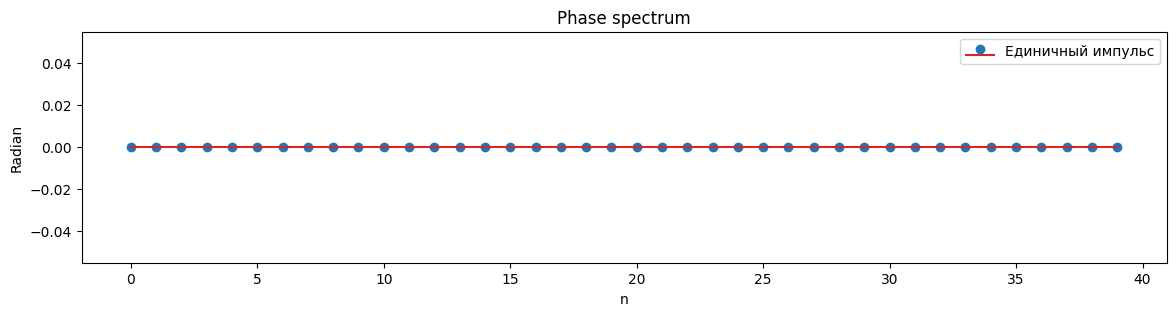

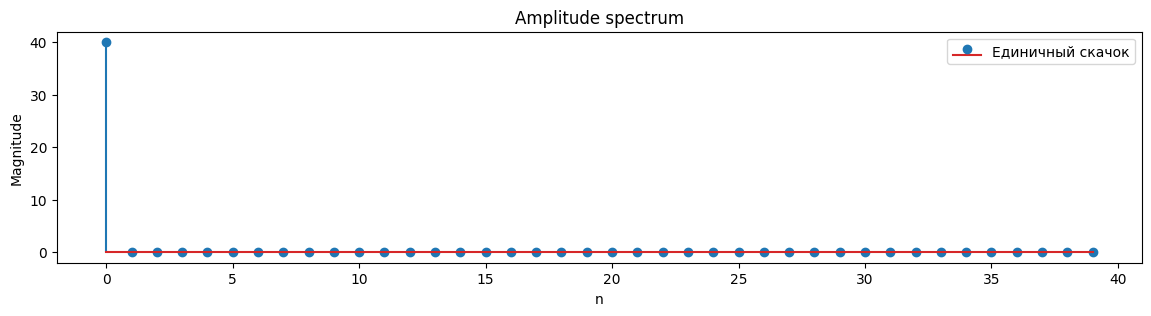

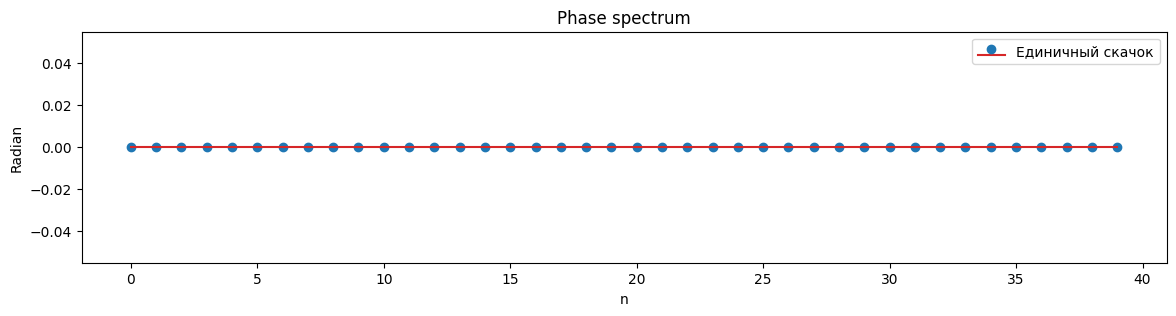

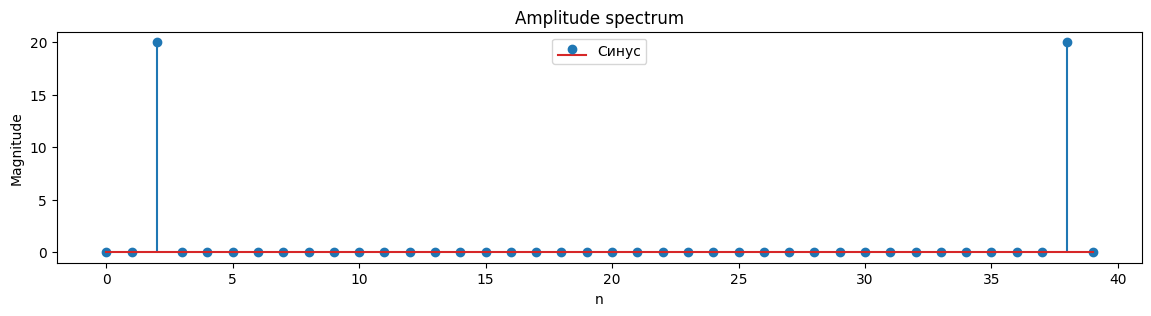

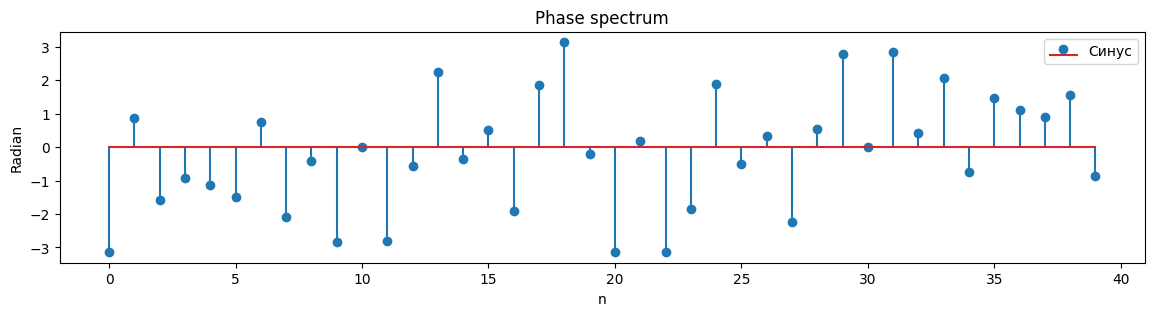

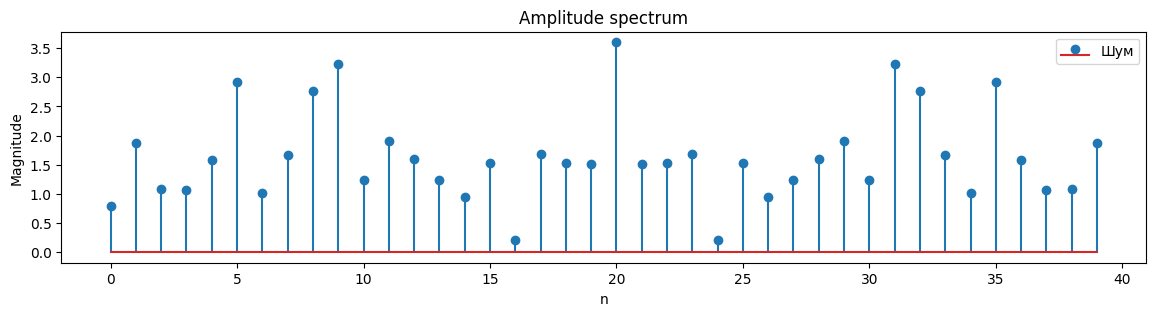

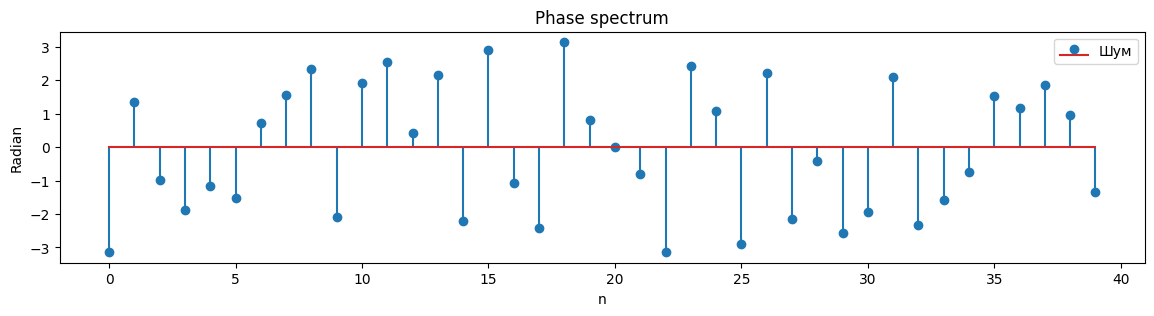

In [81]:
for name, sig in signals.items():
    spec = scipy.fft.fft(sig)
    draw_spec(spec, name=f"{name}")

### 1.Почему амплитуда всех гармоник единичного импульса равна константе?

Постоянство амплитудного спектра единичного импульса - это прямое следствие его бесконечно малой длительности во временной области, что приводит к равномерному распределению энергии по всем частотам

### 2. Какие выводы можно сделать смотря на амплитудный спектр? А на фазовый?

Амплитудный спектр показывает распределение энергии сигнала по различным частотным компонентам — по сути, отвечая на вопрос «сколько» каждой частоты содержится в сигнале.

Фазовый спектр несёт более тонкую и важную для восстановления сигнала информацию: он определяет временны́е сдвиги отдельных гармоник относительно друг друга, то есть описывает, «когда» каждая частотная составляющая вносит свой вклад в общую форму сигнала.

### 3. Как перевести номер отсчета в частоту?

Формул адля перевода выглядит следующим образом

f = k × Fs / N

k — номер отсчёта (бина) в спектре

Fs — частота дискретизации (Гц)

N — общее количество точек БПФ

f — физическая частота (Гц)

### 4. Что в фазовом спектре является полезной информацией, а что - шумом? Почему?

Полезная информация в фазовом спектре:

Линейная фаза — указывает на временно́й сдвиг всего сигнала. Если фаза меняется линейно с ростом частоты, это соответствует чистой задержке сигнала без искажений.

Структурные закономерности — плавные изменения фазы между гармониками одного тона или согласованные фазовые соотношения, которые определяют форму сигнала (например, симметрию).

Ступенчатые изменения на π — часто связаны с чётностью/нечётностью сигнала (например, скачки на π для вещественных сигналов).

Шум в фазовом спектре:

Хаотичные, несвязанные значения — случайные колебания фазы, не образующие плавных зависимостей, обычно вызваны шумом в сигнале.

Резкие скачки не около π — чаще всего возникают из-за наложения шума или ошибок квантования.

# Оконное преобразование Фурье
Преобразование Фурье делает переход из временной области в частотную, позволяя анализировать составляющие сигнал гармоники. Однако это не всегда удобно. В реальных сигналах зачастую составляющие их гармоники изменяются со временем. Например, каждая буква в слове имеет свой набор основных гармоник, и простое преобразование Фурье не сильно поможет нам определить, что было сказано. Для того, чтобы анализировать такие сигналы, обычно используется [Оконное преобразование Фурье](https://ru.wikipedia.org/wiki/Оконное_преобразование_Фурье). Такое преобразование позволяет анализировать гармоники сигнала в коротких промежутках времени и сохранить временную ось при построении спектрограммы.
# Задание 3 (2 балла)
Реализовать оконное преобразование Фурье (Short-time Fourier transform), пользуясь только библиотеками *numpy* и *scipy*. Сравнить с *librosa.stft*


In [131]:
import numpy as np
from scipy.signal import get_window

def STFT(x, n_fft=2048, hop_length=512, window='hann'):
    if isinstance(window, str):
        window = get_window(window, n_fft)
    window = np.asarray(window, dtype=np.float64)
    
    pad_width = n_fft // 2
    x_padded = np.pad(x, (pad_width, pad_width), mode='constant')
    
    n_frames = 1 + (len(x_padded) - n_fft) // hop_length
    
    stft_matrix = np.zeros((n_fft // 2 + 1, n_frames), dtype=complex)
    
    for i in range(n_frames):
        start = i * hop_length
        end = start + n_fft
        segment = x_padded[start:end]
        
        windowed_segment = segment * window
        
        spec = np.fft.fft(windowed_segment, n=n_fft)
        
        stft_matrix[:, i] = spec[:n_fft // 2 + 1]
    
    return stft_matrix

In [133]:
def test_stft(x, n_fft=2048, hop_length=512, window='hann'):
    librosa_result = librosa.stft(x, n_fft=n_fft, hop_length=hop_length, window='hann', center=True)
    result = STFT(x, n_fft=n_fft, hop_length=hop_length, window='hann')
    if librosa_result.shape != result.shape:
        print(f"Your shape {result.shape} != librosa stft shape {librosa_result.shape} ")
        return -1 
    if not np.allclose(librosa_result, result):
        print(f"Wrong results. Diff {np.abs(librosa_result-result)}")
        return -2
    return 0
        
for name, sig in signals.items():
    print(f"Checking '{name}'")
    for n_fft in (8, 4):
        for hop_length in (n_fft//4, n_fft//2):
            assert test_stft(sig, n_fft=n_fft, hop_length=hop_length)==0, \
                f"Test failed. Params n_fft {n_fft}. Hop_length {hop_length}"
    print("ok")
print("All ok!")

Checking 'Единичный импульс'
ok
Checking 'Единичный скачок'
ok
Checking 'Синус'
ok
Checking 'Шум'
ok
All ok!


Определим функцию для отрисовки

In [135]:
# Определим функцию для отрисовки
def draw_stft(X, sr, figsize=(14, 5)):
    plt.figure(figsize=figsize)
    # X - комплекстная спектрограмма 
    # Для получения энергии достаточно взять модуль
    Xdb = librosa.amplitude_to_db(abs(X))
    librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz')
    plt.show()

# Анализ сигналов
Теперь можно приступить к анализу звуковых сигналов.
Во время анализа сигналов нам понадобятся все определенные выше инструменты. 


----------------------------------
## Анализ паровозного гудка
Начнем с простого сигнала, состоящего из нескольких основных гармоник и шума.

Загрузим аудио файл с паровозным гудком

In [141]:
# Загрузим аудио файл с паровозным гудком
train_whistle, tw_sr = librosa.core.load("content/train_whistle.wav")
print(f"Len is {len(train_whistle)} ( ). Sample rate is {tw_sr}")
player = ipd.Audio(train_whistle, rate=tw_sr)
ipd.display(player)
draw_waveform(train_whistle, sr=tw_sr)

Len is 82175 ( ). Sample rate is 22050


Построим гудок паровоза в частотной области

Гудок паровоза в частотной области


<Figure size 1400x500 with 0 Axes>

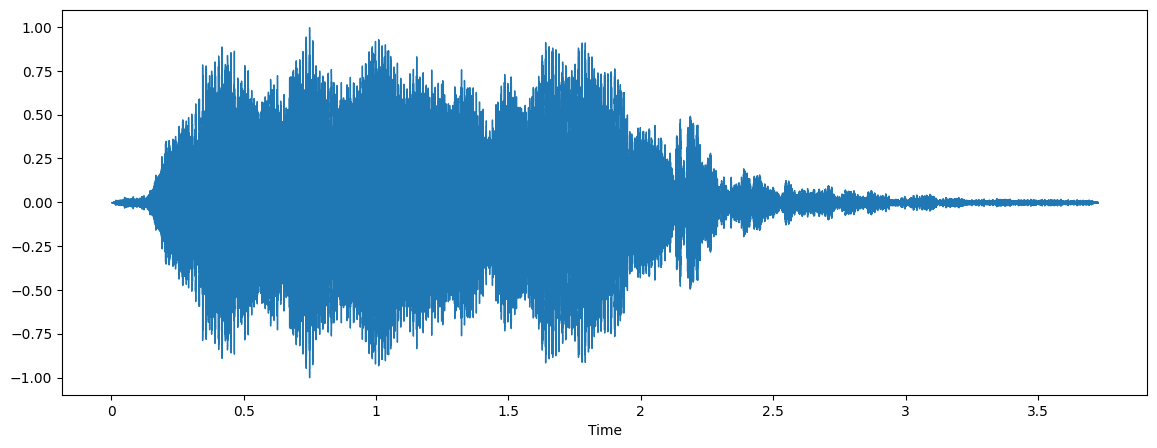

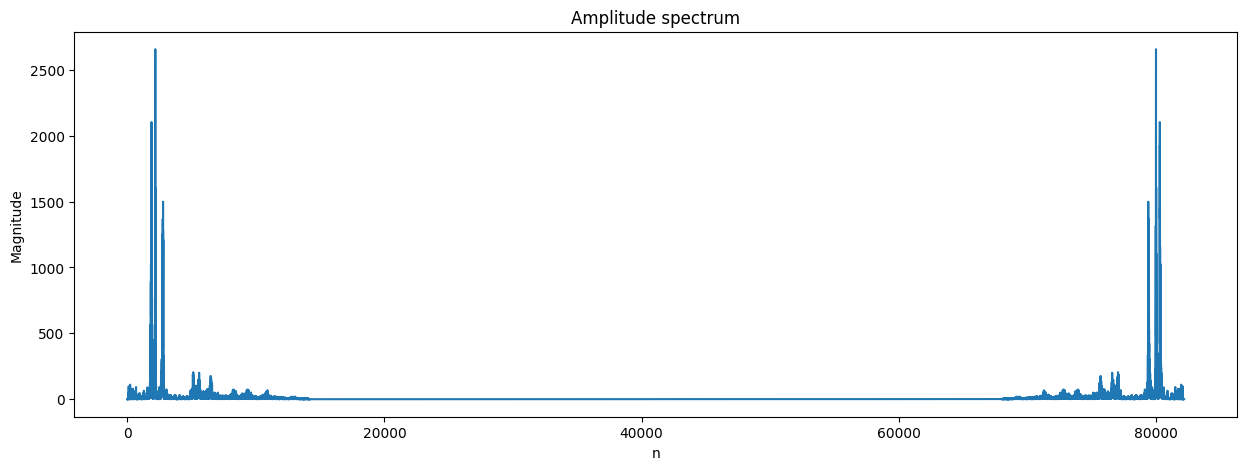

In [143]:
train_whistle_spec = scipy.fft.fft(train_whistle)
print("Гудок паровоза в частотной области")
draw_spec(train_whistle_spec, draw_p=False, figsize=(15,5))

# Задание 4 (2 балла)
Определите 3 основные гармоники паровозного гудка.

Ответ округлите до двух знаков после запятой.


Амплитудный спектр

In [324]:
import numpy as np
from scipy.signal import find_peaks

# Анализ частотного состава сигнала
signal_length = len(train_whistle)
spectrum = np.fft.fft(train_whistle)
magnitude = np.abs(spectrum)
frequency_axis = np.fft.fftfreq(signal_length, d=1.0 / tw_sr)

positive_range = signal_length // 2
freq_pos = frequency_axis[:positive_range]
amp_pos = magnitude[:positive_range]
min_peak_level = 0.05 * np.max(amp_pos)
step_size = max(1, int(0.005 * positive_range))

found_peaks, _ = find_peaks(amp_pos, height=min_peak_level, distance=step_size)

retry_count = 0
while len(found_peaks) < 3 and retry_count < 6:
    retry_count += 1
    min_peak_level *= 0.6
    step_size = max(1, step_size // 2)
    found_peaks, _ = find_peaks(amp_pos, height=min_peak_level, distance=step_size)

if len(found_peaks) >= 3:
    peak_strengths = amp_pos[found_peaks]
    strongest_indices = found_peaks[np.argsort(peak_strengths)[-3:]]
else:
    candidate_indices = np.argsort(amp_pos)[-6:]
    selected_peaks = []
    for candidate in candidate_indices[::-1]:
        if not selected_peaks or min(abs(candidate - p) for p in selected_peaks) > 1:
            selected_peaks.append(candidate)
        if len(selected_peaks) == 3:
            break
    strongest_indices = np.array(selected_peaks)

main_frequencies = freq_pos[strongest_indices]
intensity_values = amp_pos[strongest_indices]
sorted_by_intensity = main_frequencies[np.argsort(intensity_values)[::-1]]

### 1 гармоника

In [327]:
freq1 = round(harmonic_freqs_sorted[0], 2)
print(f"1 гармоника: {freq1} Гц")

1 гармоника: 585.76 Гц


### 2 гармоника

In [330]:
freq2 = round(harmonic_freqs_sorted[1], 2)
print(f"2 гармоника: {freq2} Гц")

2 гармоника: 505.8 Гц


### 3 гармоника

In [333]:
freq3 = round(harmonic_freqs_sorted[2], 2)
print(f"3 гармоника: {freq3} Гц")

3 гармоника: 747.3 Гц


### Тест

In [336]:
# task_answer = [ freq1, freq2, freq3 ]
task_answer = [freq1, freq2, freq3]

In [338]:
assert type(task_answer) == list or type(task_answer) == np.ndarray, \
        f"Wrong answer type. Expected list or numpy array. Got {type(task_answer)}"
assert len(task_answer) == 3, \
        f"Wrong len {len(task_answer)}."
assert (round(sum(task_answer)) == 1677 and round(np.var(task_answer)) == 1407) or \
        (abs(sum(task_answer)  - 1836) <= 3 and abs(np.var(task_answer) - 10153) <= 181), \
        f"Wrong freqs"
print("Correct!")       

Correct!


Теперь попробуйте сгенерировать сигнал, состоящий только из этих гармоник. Воспроизведите сигнал.

Воспроизведение синтетического сигнала с гармониками:
585.76 Гц, 505.8 Гц, 747.3 Гц


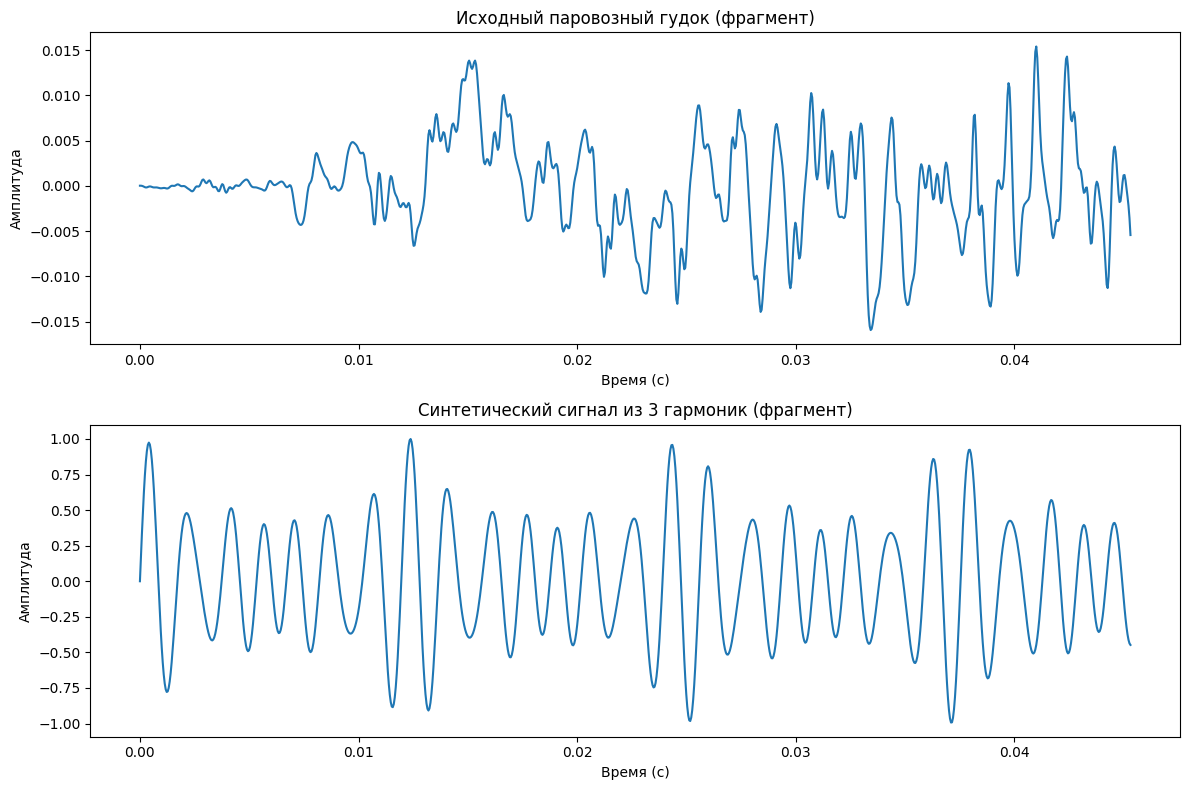

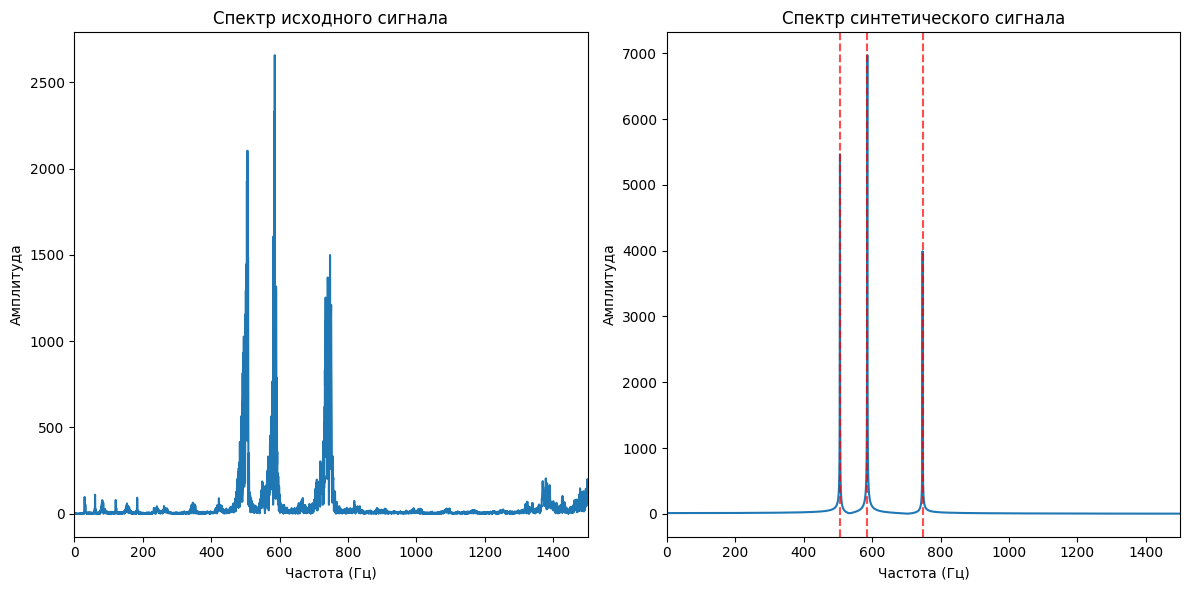

In [340]:
duration = 2.0 
t = np.linspace(0, duration, int(tw_sr * duration))

harmonic1 = np.sin(2 * np.pi * freq1 * t)
harmonic2 = np.sin(2 * np.pi * freq2 * t) 
harmonic3 = np.sin(2 * np.pi * freq3 * t)

synthetic_signal = harmonic1 + 0.7 * harmonic2 + 0.5 * harmonic3
synthetic_signal = synthetic_signal / np.max(np.abs(synthetic_signal))

print("Воспроизведение синтетического сигнала с гармониками:")
print(f"{freq1} Гц, {freq2} Гц, {freq3} Гц")

player = ipd.Audio(synthetic_signal, rate=tw_sr)
ipd.display(player)

# Визуализируем результат
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(t[:1000], train_whistle[:1000])
plt.title('Исходный паровозный гудок (фрагмент)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')

plt.subplot(2, 1, 2) 
plt.plot(t[:1000], synthetic_signal[:1000])
plt.title('Синтетический сигнал из 3 гармоник (фрагмент)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
spec_original = np.abs(np.fft.fft(train_whistle))
freqs_original = np.fft.fftfreq(len(train_whistle), d=1/tw_sr)
positive_mask = freqs_original > 0
plt.plot(freqs_original[positive_mask], spec_original[positive_mask])
plt.title('Спектр исходного сигнала')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 1500)

plt.subplot(1, 2, 2)
spec_synthetic = np.abs(np.fft.fft(synthetic_signal))
freqs_synthetic = np.fft.fftfreq(len(synthetic_signal), d=1/tw_sr)
positive_mask = freqs_synthetic > 0
plt.plot(freqs_synthetic[positive_mask], spec_synthetic[positive_mask])
plt.title('Спектр синтетического сигнала')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 1500)

for freq in [freq1, freq2, freq3]:
    plt.axvline(x=freq, color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Анализ двухтонального многочастотного сигнала
Теперь расмотрим более сложный сигнал - [DTMF](https://en.wikipedia.org/wiki/Dual-tone_multi-frequency_signaling). Такие сигналы используются для автоматизации набора телефонного номера. 

# Задание 5 (2 балла)
В данном аудио закодирован трехзначный номер. Используя таблицу с [wiki]:(https://ru.wikipedia.org/wiki/DTMF) определите, что за номер закодирован.


Визуализация

In [209]:
#dtmf.wav
dtmf, dtmf_sr = librosa.core.load("content/dtmf.wav")
print(f"Len is {len(dtmf)}. Sample rate is {dtmf_sr}")
player = ipd.Audio(dtmf, rate=dtmf_sr)
ipd.display(player)
draw_waveform(dtmf, sr=dtmf_sr)

Len is 243102. Sample rate is 22050


Построим спектрограмму для анализа

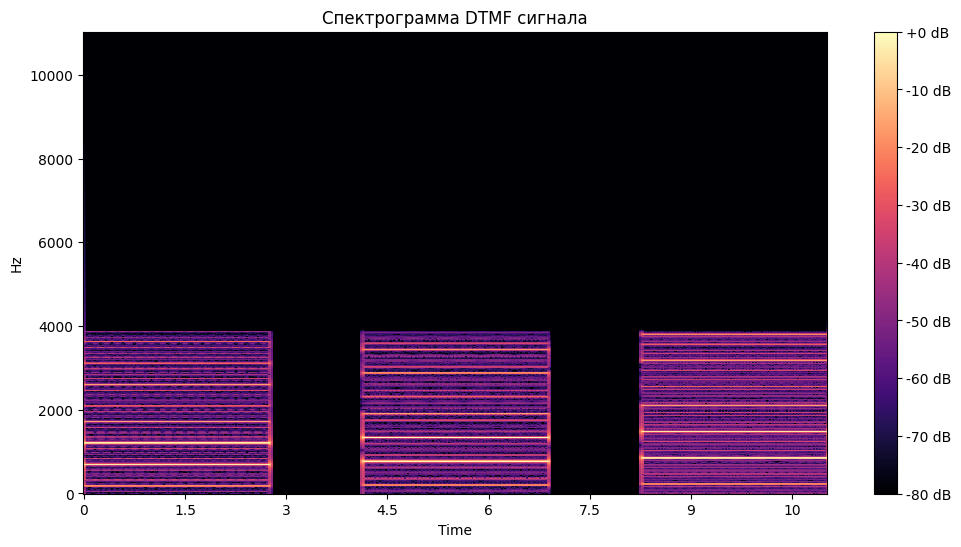

In [343]:
plt.figure(figsize=(12, 6))
D = librosa.stft(dtmf)
librosa.display.specshow(librosa.amplitude_to_db(np.abs(D), ref=np.max), 
                       sr=dtmf_sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Спектрограмма DTMF сигнала')
plt.show()

In [347]:
def dtmf_digit(low_freq, high_freq):
    dtmf_table = {
        (697, 1209): '1', (697, 1336): '2', (697, 1477): '3',
        (770, 1209): '4', (770, 1336): '5', (770, 1477): '6', 
        (852, 1209): '7', (852, 1336): '8', (852, 1477): '9',
        (941, 1209): '*', (941, 1336): '0', (941, 1477): '#'
    }
    
    # Ищем ближайшую пару частот в таблице
    for (f1, f2), digit in dtmf_table.items():
        if abs(low_freq - f1) <= 20 and abs(high_freq - f2) <= 20:
            return digit
    return '?'

In [351]:
# Анализ DTMF сигнала
def decode_dtmf(signal, sr):
    # Разбиваем сигнал на сегменты (предполагаем 3 цифры)
    segment_length = len(signal) // 3
    digits = []
    
    for i in range(3):
        start = i * segment_length
        end = start + segment_length
        segment = signal[start:end]
        spec = np.fft.fft(segment)
        freqs = np.fft.fftfreq(len(segment), d=1/sr)
        amplitude = np.abs(spec)
        
        low_freq_mask = (freqs > 600) & (freqs < 1000)
        high_freq_mask = (freqs > 1100) & (freqs < 1600)
        
        low_freqs = freqs[low_freq_mask]
        low_amps = amplitude[low_freq_mask]
        high_freqs = freqs[high_freq_mask] 
        high_amps = amplitude[high_freq_mask]
        
        low_peak_idx = np.argmax(low_amps)
        high_peak_idx = np.argmax(high_amps)
        
        low_freq = low_freqs[low_peak_idx]
        high_freq = high_freqs[high_peak_idx]
        
        digit = dtmf_digit(low_freq, high_freq)
        digits.append(digit)
        
        print(f"Сегмент {i+1}: низкая частота {low_freq:.0f} Гц, высокая частота {high_freq:.0f} Гц цифра '{digit}'")
    
    return ''.join(digits)

# Декодируем номер
phone_number = decode_dtmf(dtmf, dtmf_sr)
print(f"\nЗакодированный номер: {phone_number}")

Сегмент 1: низкая частота 697 Гц, высокая частота 1209 Гц цифра '1'
Сегмент 2: низкая частота 770 Гц, высокая частота 1336 Гц цифра '5'
Сегмент 3: низкая частота 852 Гц, высокая частота 1477 Гц цифра '9'

Закодированный номер: 159


### 1 число

In [364]:
first = 1

### 2 число

In [367]:
second = 5

### 3 число

In [370]:
third = 9

### Тест

In [377]:
phone_number = [first, second, third]

In [379]:
assert type(phone_number) == list or type(phone_number) == np.ndarray, \
        f"Wrong answer type. Expected list or numpy array. Got {type(phone_number)}"
assert len(phone_number) == 3, \
        f"Wrong len {len(phone_number)}."
assert round(np.mean(phone_number)) == 5 and round(np.var(phone_number)) == 11 , \
        f"Wrong number"
assert hashlib.md5(''.join(map(str, phone_number)).encode()).hexdigest() == "140f6969d5213fd0ece03148e62e461e", \
        f"Wrong hash. How did you pass mean/var test?"
print("Correct!")   

Correct!
